# Part II · Limitation L1 — Lagged Exposure
**Task 8** | *Worksheet §Part II, Limitation L1 (25 min)*

## The problem: simultaneity

The original exposure indicator is
$$E_k(t) = \mathbf{1}[m(k,t) > 0]$$
where $m(k,t)$ counts neighbours **jumping at the same frame $t$** as the focal cell is observed.  
The future self-jump window is $(t, t+W]$.

**Issue:** the neighbour's jump and the focal cell's future window are anchored to the same frame.  
There is no guarantee of temporal precedence — both cells could be responding
to the same upstream stimulus simultaneously.

**Fix:** use a **lagged exposure**
$$E_k^{(\tau)}(t) = \mathbf{1}[m(k,\, t - \tau) > 0]$$
For $\tau \geq 1$ the neighbour's jump *strictly precedes* the focal cell's look-ahead window,
providing genuine temporal precedence.

If ERK truly propagates from neighbour to focal cell, we expect $\mathrm{RR}^{(\tau)}$
to peak at a small lag $\tau^*$ and decay toward 1 at large $\tau$.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYSIS_ROOT = PROJECT_ROOT / "analysis_outputs"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

NODE_FILES = {
    "WT": ANALYSIS_ROOT / "exp_1_site_1_ERKKTR_ratio" / "nodes.csv.gz",
    "PIK3CA_H1047R": ANALYSIS_ROOT / "exp_1_site_13_ERKKTR_ratio" / "nodes.csv.gz",
    "PTEN_del": ANALYSIS_ROOT / "exp_1_site_17_ERKKTR_ratio" / "nodes.csv.gz",
}

print("PROJECT_ROOT:", PROJECT_ROOT)
for mutation, path in NODE_FILES.items():
    print(mutation, path.exists(), path)

PROJECT_ROOT: c:\Users\olcia\Downloads\spatiotemporal-starter
WT True c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs\exp_1_site_1_ERKKTR_ratio\nodes.csv.gz
PIK3CA_H1047R True c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs\exp_1_site_13_ERKKTR_ratio\nodes.csv.gz
PTEN_del True c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs\exp_1_site_17_ERKKTR_ratio\nodes.csv.gz


In [2]:
import sys
import subprocess

DATA_PATH = PROJECT_ROOT / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "01-readme-experiment-description_2022-04-05.csv"
SCRIPT_PATH = PROJECT_ROOT / "scripts" / "spatiotemporal_signal_propagation.py"

sites_to_generate = {
    "WT": 1,
    "PIK3CA_H1047R": 13,
    "PTEN_del": 17,
}

for mutation, site_id in sites_to_generate.items():
    nodes_path = ANALYSIS_ROOT / f"exp_1_site_{site_id}_ERKKTR_ratio" / "nodes.csv.gz"
    
    if nodes_path.exists():
        print(f"{mutation}: already exists, skipping")
        continue

    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--data-path", str(DATA_PATH),
        "--meta-path", str(META_PATH),
        "--exp-id", "1",
        "--site-id", str(site_id),
        "--signal-col", "ERKKTR_ratio",
        "--spatial-radius", "60",
        "--future-window-frames", "3",
        "--jump-quantile", "0.9",
        "--output-dir", str(ANALYSIS_ROOT),
    ]

    print(f"\nGenerating {mutation}, site {site_id}")
    print(" ".join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True)

    print("RETURN CODE:", result.returncode)
    print(result.stdout)
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(f"Failed to generate nodes for {mutation}, site {site_id}")

WT: already exists, skipping
PIK3CA_H1047R: already exists, skipping
PTEN_del: already exists, skipping


In [3]:
for mutation, path in NODE_FILES.items():
    print(mutation, path.exists(), path)

WT True c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs\exp_1_site_1_ERKKTR_ratio\nodes.csv.gz
PIK3CA_H1047R True c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs\exp_1_site_13_ERKKTR_ratio\nodes.csv.gz
PTEN_del True c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs\exp_1_site_17_ERKKTR_ratio\nodes.csv.gz


In [4]:
MAX_LAG = 6
FRAME_MINUTES = 5

def add_lagged_exposure_columns(nodes, max_lag=MAX_LAG):
    nodes = nodes.sort_values(["track_id", "Image_Metadata_T"]).reset_index(drop=True)

    for tau in range(1, max_lag + 1):
        nodes[f"lagged_exposure_{tau}"] = (
            nodes.groupby("track_id")["neighbor_jump_now"]
                 .shift(tau)
                 .fillna(False)
                 .astype(bool)
        )

    return nodes


def compute_lagged_rr(nodes, mutation, max_lag=MAX_LAG, frame_minutes=FRAME_MINUTES):
    nodes = add_lagged_exposure_columns(nodes, max_lag=max_lag)

    results = []

    for tau in range(max_lag + 1):
        col = "neighbor_jump_now" if tau == 0 else f"lagged_exposure_{tau}"

        exposed = nodes[nodes[col] == True]
        unexposed = nodes[nodes[col] == False]

        p_exp = exposed["future_self_jump"].mean()
        p_unexp = unexposed["future_self_jump"].mean()

        rr = p_exp / p_unexp if p_unexp > 0 else np.nan
        rd = p_exp - p_unexp

        results.append({
            "mutation": mutation,
            "tau_frames": tau,
            "tau_minutes": tau * frame_minutes,
            "n_exposed": len(exposed),
            "n_unexposed": len(unexposed),
            "p_exposed": p_exp,
            "p_unexposed": p_unexp,
            "risk_difference": rd,
            "RR": rr,
        })

    return pd.DataFrame(results)

In [5]:
lagged_tables = []

for mutation, path in NODE_FILES.items():
    nodes = pd.read_csv(path)
    lagged_table = compute_lagged_rr(nodes, mutation)
    lagged_tables.append(lagged_table)

lagged_results = pd.concat(lagged_tables, ignore_index=True)
lagged_results

C:\Users\olcia\AppData\Local\Temp\ipykernel_10568\3222461312.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\olcia\AppData\Local\Temp\ipykernel_10568\3222461312.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\olcia\AppData\Local\Temp\ipykernel_10568\3222461312.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.n

,mutation,tau_frames,tau_minutes,n_exposed,n_unexposed,p_exposed,p_unexposed,risk_difference,RR
0,WT,0,0,146620,210012,0.131455,0.074867,0.056588,1.755850
1,WT,1,5,145714,210918,0.128443,0.077191,0.051252,1.663966
2,WT,2,10,144813,211819,0.124830,0.079880,0.044950,1.562728
3,WT,3,15,143980,212652,0.120621,0.082905,0.037716,1.454922
4,WT,4,20,143194,213438,0.116876,0.085556,0.031320,1.366073
5,WT,5,25,142405,214227,0.113641,0.087823,0.025818,1.293978
6,WT,6,30,141705,214927,0.110779,0.089793,0.020986,1.233716
7,PIK3CA_H1047R,0,0,33713,142137,0.194910,0.068547,0.126363,2.843469
8,PIK3CA_H1047R,1,5,33507,142343,0.169577,0.074693,0.094884,2.270319
9,PIK3CA_H1047R,2,10,33299,142551,0.144959,0.080582,0.064378,1.798911


In [6]:
optimal_lags = (
    lagged_results
    .sort_values("RR", ascending=False)
    .groupby("mutation")
    .head(1)
    .sort_values("mutation")
    .reset_index(drop=True)
)

summary_table = optimal_lags.rename(columns={
    "tau_frames": "optimal_lag_tau_star",
    "tau_minutes": "optimal_lag_minutes",
    "RR": "max_RR",
})[[
    "mutation",
    "optimal_lag_tau_star",
    "optimal_lag_minutes",
    "max_RR",
]]

summary_table

,mutation,optimal_lag_tau_star,optimal_lag_minutes,max_RR
0,PIK3CA_H1047R,0,0,2.843469
1,PTEN_del,0,0,1.573125
2,WT,0,0,1.755850


In [7]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

lagged_results.to_csv(OUTPUT_DIR / "lagged_exposure_full_results.csv", index=False)
summary_table.to_csv(OUTPUT_DIR / "lagged_exposure_table.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "lagged_exposure_full_results.csv")
print(OUTPUT_DIR / "lagged_exposure_table.csv")

Saved:
c:\Users\olcia\Downloads\spatiotemporal-starter\outputs\lagged_exposure_full_results.csv
c:\Users\olcia\Downloads\spatiotemporal-starter\outputs\lagged_exposure_table.csv


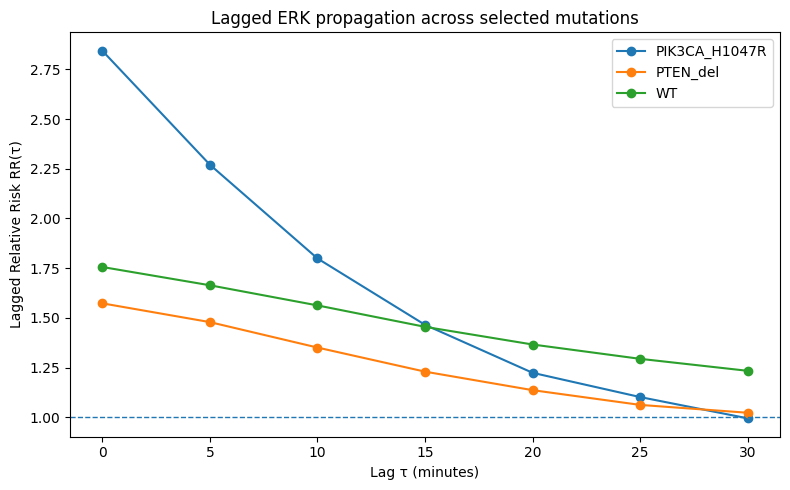

In [8]:
plt.figure(figsize=(8, 5))

for mutation, df in lagged_results.groupby("mutation"):
    plt.plot(
        df["tau_minutes"],
        df["RR"],
        marker="o",
        label=mutation
    )

plt.axhline(1, linestyle="--", linewidth=1)
plt.xlabel("Lag τ (minutes)")
plt.ylabel("Lagged Relative Risk RR(τ)")
plt.title("Lagged ERK propagation across selected mutations")
plt.legend()
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "lagged_exposure_plot.png", dpi=300)
plt.show()